# Numerical verification of Floquet--Koopman eigenfunctionals

This notebook implements the six numerical tests proposed for the paper

> **Koopman Eigenfunctionals Associated with Floquet Modes of Attracting Periodic Orbits in Parabolic Semiflows.**

The purpose is **not** to introduce a new data-driven Koopman algorithm.  The computations mirror the theoretical construction:

$$
\text{Floquet slow mode}
\longrightarrow
\text{return-map eigenfunction }\chi
\longrightarrow
\text{section-to-continuous-time extension }\psi
\longrightarrow
\text{extension to the basin of attraction}
\longrightarrow
\text{the Koopman eigenfunction equation and the Koopman eigenvalue lattice}.
$$

The six experiments are:

1. verification of the Floquet spectrum and the unique slow transverse multiplier;
2. convergence of the return-map limit defining the section eigenfunction $\chi$;
3. residual test for the continuous-time Koopman eigenfunction equation;
4. comparison of $D\psi$ with the adjoint Floquet covector;
5. verification of the Koopman eigenvalue lattice $\lambda_\star+in\omega_0$;
6. direct tests of return-choice independence in section-to-continuous-time extension and entry-time independence in extension to the basin of attraction.

Every experiment has a separate **computation cell** and **plotting cell**.  Each plotting cell saves both PDF and PNG files and prints a paper-ready caption directly below the figure.


## Model: a spatially extended Stuart--Landau oscillator

We consider

$$
\partial_t W
=d\,\partial_{xx}W+(1-|W|^2)W+i\omega_0W,
\qquad x\in(0,L),
$$

with homogeneous Neumann boundary conditions.  This is precisely the **Stuart--Landau normal form with diffusion**; equivalently, it is a particularly simple $\lambda$-$\omega$ or complex Ginzburg--Landau reaction--diffusion system.

The spatially homogeneous periodic orbit is

$$
W_\Gamma(x,t)=e^{i\omega_0t},
\qquad T=\frac{2\pi}{\omega_0}.
$$

In the co-rotating variable $Z=e^{-i\omega_0t}W$,

$$
\partial_t Z=d\,\partial_{xx}Z+(1-|Z|^2)Z,
$$

and the periodic orbit becomes the equilibrium $Z\equiv1$.  Writing $Z=1+a+ib$, the linearization is

$$
a_t=d a_{xx}-2a,
\qquad
b_t=d b_{xx}.
$$

For Neumann cosine modes, the transverse exponents are

$$
-2-d\left(\frac{n\pi}{L}\right)^2,
\qquad
-d\left(\frac{n\pi}{L}\right)^2,
\quad n\ge1.
$$

The constant $b$-mode is the neutral phase direction.  We choose parameters so that

$$
\lambda_\star=-d\left(\frac{\pi}{L}\right)^2
$$

is the unique slowest transverse exponent.


In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import dct, idct
from IPython.display import display, Markdown

# -----------------------------------------------------------------------------
# Publication-oriented plotting defaults.
# These sizes are chosen to remain legible after insertion into an 11 pt paper.
# Adjust PAPER_FIGSIZE or the rcParams below if the journal uses a narrower column.
# -----------------------------------------------------------------------------
PAPER_FIGSIZE = (6.25, 3.85)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "font.size": 10.5,
    "axes.titlesize": 11.0,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.3,
    "figure.titlesize": 11.0,
    "axes.linewidth": 0.85,
    "lines.linewidth": 1.6,
    "lines.markersize": 5.2,
    "legend.frameon": False,
    "savefig.dpi": 300,
    "figure.dpi": 120,
})

FIGURE_DIR = Path("figures")
RESULT_DIR = Path("results")
FIGURE_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

CAPTIONS = {}


def finish_figure(stem: str, caption_text: str) -> None:
    """Save the current figure, display it, and print/store its caption."""
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / f"{stem}.png", bbox_inches="tight", dpi=300)
    plt.show()

    CAPTIONS[stem] = caption_text
    caption_file = FIGURE_DIR / "figure_captions.md"
    caption_file.write_text(
        "\n\n".join(f"**{key}.** {value}" for key, value in CAPTIONS.items()),
        encoding="utf-8",
    )
    display(Markdown(f"**Figure caption.** {caption_text}"))


print(f"Figures will be saved in: {FIGURE_DIR.resolve()}")
print(f"Tables will be saved in:  {RESULT_DIR.resolve()}")


Figures will be saved in: C:\Users\xyc93\Documents\Koopman_Semiflows\figures
Tables will be saved in:  C:\Users\xyc93\Documents\Koopman_Semiflows\results


In [2]:

# -----------------------------------------------------------------------------
# Model and discretization parameters
# -----------------------------------------------------------------------------
L = np.pi
DIFFUSION = 0.12
OMEGA0 = 1.0
PERIOD = 2.0 * np.pi / OMEGA0

N_X = 65                     # endpoint-inclusive cosine grid
STEPS_PER_PERIOD = 300       # Strang-splitting steps per temporal period
DT_MAX = PERIOD / STEPS_PER_PERIOD

X_GRID = np.linspace(0.0, L, N_X)
COSINE_WAVENUMBERS = np.arange(N_X) * np.pi / L

LAMBDA_STAR = -DIFFUSION * (np.pi / L) ** 2
MU_STAR = np.exp(LAMBDA_STAR * PERIOD)

print("Parameter summary")
print("-----------------")
print(f"L                       = {L:.8f}")
print(f"diffusion d             = {DIFFUSION:.8f}")
print(f"omega_0                 = {OMEGA0:.8f}")
print(f"period T                = {PERIOD:.8f}")
print(f"spatial grid points     = {N_X}")
print(f"steps per period        = {STEPS_PER_PERIOD}")
print(f"slow exponent lambda_*  = {LAMBDA_STAR:.8f}")
print(f"slow multiplier mu_*    = {MU_STAR:.8f}")


Parameter summary
-----------------
L                       = 3.14159265
diffusion d             = 0.12000000
omega_0                 = 1.00000000
period T                = 6.28318531
spatial grid points     = 65
steps per period        = 300
slow exponent lambda_*  = -0.12000000
slow multiplier mu_*    = 0.47048922


In [3]:

# -----------------------------------------------------------------------------
# Cosine pseudospectral Strang solver in the co-rotating frame
# -----------------------------------------------------------------------------

def _dct1_complex(values: np.ndarray) -> np.ndarray:
    """Unnormalized DCT-I, applied separately to real and imaginary parts."""
    return dct(values.real, type=1) + 1j * dct(values.imag, type=1)


def _idct1_complex(coefficients: np.ndarray) -> np.ndarray:
    """Inverse of the unnormalized DCT-I used above."""
    return idct(coefficients.real, type=1) + 1j * idct(coefficients.imag, type=1)


def reaction_exact(z: np.ndarray, step_size: float) -> np.ndarray:
    """Exact flow of z_t=(1-|z|^2)z over one pointwise reaction step."""
    radius_squared = np.abs(z) ** 2
    denominator = np.sqrt(
        radius_squared + (1.0 - radius_squared) * np.exp(-2.0 * step_size)
    )
    return z / denominator


def diffusion_exact(z: np.ndarray, step_size: float) -> np.ndarray:
    """Exact Neumann diffusion step in the cosine representation."""
    coefficients = _dct1_complex(z)
    coefficients *= np.exp(
        -DIFFUSION * COSINE_WAVENUMBERS**2 * step_size
    )
    return _idct1_complex(coefficients)


def strang_step(z: np.ndarray, step_size: float) -> np.ndarray:
    """Second-order Strang step for the co-rotating reaction--diffusion PDE."""
    z = reaction_exact(z, 0.5 * step_size)
    z = diffusion_exact(z, step_size)
    z = reaction_exact(z, 0.5 * step_size)
    return z


def evolve(z0: np.ndarray, final_time: float, dt_max: float = DT_MAX) -> np.ndarray:
    """Evolve one state to a requested final time."""
    if final_time < 0.0:
        raise ValueError("The parabolic semiflow is used only for nonnegative time.")

    z = np.asarray(z0, dtype=complex).copy()
    current_time = 0.0
    while current_time < final_time - 1.0e-13:
        step_size = min(dt_max, final_time - current_time)
        z = strang_step(z, step_size)
        current_time += step_size
    return z


def evolve_to_targets(
    z0: np.ndarray,
    target_times: np.ndarray,
    dt_max: float = DT_MAX,
) -> list[np.ndarray]:
    """Evolve once and return states at a sorted or unsorted list of target times."""
    target_times = np.asarray(target_times, dtype=float)
    if np.any(target_times < -1.0e-14):
        raise ValueError("All target times must be nonnegative.")

    ordering = np.argsort(target_times)
    sorted_targets = target_times[ordering]
    outputs: list[np.ndarray | None] = [None] * len(target_times)

    z = np.asarray(z0, dtype=complex).copy()
    current_time = 0.0
    for original_index, target_time in zip(ordering, sorted_targets):
        while current_time < target_time - 1.0e-13:
            step_size = min(dt_max, target_time - current_time)
            z = strang_step(z, step_size)
            current_time += step_size
        outputs[original_index] = z.copy()

    return [value for value in outputs if value is not None]


def modal_projection(values: np.ndarray, mode: int) -> float:
    """Continuous cosine coefficient approximated by the trapezoidal rule."""
    cosine = np.cos(mode * np.pi * X_GRID / L)
    normalization = 1.0 / L if mode == 0 else 2.0 / L
    return float(normalization * np.trapezoid(values * cosine, X_GRID))


def seed_observable(z: np.ndarray) -> float:
    """Seed aligned with the slow adjoint Floquet covector."""
    return modal_projection(z.imag, mode=1)


def make_section_state(
    slow_amplitude: float,
    fast_amplitude: float = 0.10,
    radial_amplitude: float = 0.08,
) -> np.ndarray:
    """
    Construct a phase-zero state satisfying
        z(L-x)=conj(z(x)).
    This symmetry keeps the asymptotic phase equal to zero in the rotating frame.
    """
    real_part = 1.0 + radial_amplitude * np.cos(2.0 * np.pi * X_GRID / L)
    imaginary_part = (
        slow_amplitude * np.cos(np.pi * X_GRID / L)
        + fast_amplitude * np.cos(3.0 * np.pi * X_GRID / L)
    )
    return real_part + 1j * imaginary_part


def time_to_next_section(phase_angle: float) -> float:
    """Forward time to the phase section theta=0 mod 2pi."""
    reduced_phase = float(np.mod(phase_angle, 2.0 * np.pi))
    if min(abs(reduced_phase), abs(reduced_phase - 2.0 * np.pi)) < 1.0e-12:
        return 0.0
    return (2.0 * np.pi - reduced_phase) / OMEGA0


def chi_approximation(z_on_section: np.ndarray, return_depth: int) -> float:
    """Finite-return approximation chi_m=mu_*^{-m} p(P^m z)."""
    horizon = return_depth * PERIOD
    return float(np.exp(-LAMBDA_STAR * horizon) * seed_observable(evolve(z_on_section, horizon)))


def psi_approximation(
    z_in_rotating_frame: np.ndarray,
    phase_angle: float,
    return_depth: int,
) -> float:
    """
    Forward-only suspended approximation
        psi_m(z,theta)=exp[-lambda_*(tau+mT)] p(S^{tau+mT}z).
    """
    hitting_time = time_to_next_section(phase_angle)
    horizon = hitting_time + return_depth * PERIOD
    future_state = evolve(z_in_rotating_frame, horizon)
    return float(np.exp(-LAMBDA_STAR * horizon) * seed_observable(future_state))


def psi_time_series(
    z0: np.ndarray,
    initial_phase: float,
    sample_times: np.ndarray,
    return_depth: int,
) -> np.ndarray:
    """
    Efficiently evaluate the forward-suspended psi_m along one trajectory.

    Between two consecutive section hits, all sample points use the same future
    section state.  Only forward evolution is used.
    """
    sample_times = np.asarray(sample_times, dtype=float)
    first_hit = time_to_next_section(initial_phase)
    maximum_time = float(np.max(sample_times))

    if maximum_time <= first_hit + 1.0e-12:
        section_times = np.array([first_hit])
    else:
        number_of_periods = int(np.ceil((maximum_time - first_hit) / PERIOD))
        section_times = first_hit + np.arange(number_of_periods + 1) * PERIOD

    future_times = section_times + return_depth * PERIOD
    future_states = evolve_to_targets(z0, future_times)
    future_seeds = np.array([seed_observable(state) for state in future_states])

    section_indices = np.searchsorted(
        section_times,
        sample_times - 1.0e-10,
        side="left",
    )
    next_sections = section_times[section_indices]
    remaining_forward_times = next_sections - sample_times + return_depth * PERIOD

    return np.exp(-LAMBDA_STAR * remaining_forward_times) * future_seeds[section_indices]


# Basic solver sanity checks.
constant_state = np.ones(N_X, dtype=complex)
constant_diffusion_error = np.max(np.abs(diffusion_exact(constant_state, PERIOD) - constant_state))
print(f"Constant-mode diffusion error: {constant_diffusion_error:.3e}")


Constant-mode diffusion error: 0.000e+00


### Phase convention used in Experiments 2--6

The tested initial states satisfy

$$
Z(L-x)=\overline{Z(x)}.
$$

This reflection--conjugation symmetry is preserved by the co-rotating PDE and keeps the limiting rotating-frame phase equal to zero.  Multiplication by $e^{i\theta}$ therefore supplies a known phase $\theta$, so the next forward section-hitting time is available without estimating an isochron numerically.  The restriction is made only to obtain a clean theorem-verification benchmark; the abstract theory is not restricted to this symmetry class.



## Experiment 1 — Floquet spectrum and the unique slow transverse multiplier

**Theory checked.**  This experiment verifies the spectral hypotheses used by the paper: the constant phase mode is neutral, all transverse modes are stable, and the $n=1$ phase branch gives a simple, isolated, unique slow transverse multiplier.

The numerical multipliers are obtained by applying the nonlinear one-period map to small perturbations and taking finite-difference modal ratios.  They are compared with the exact linearized formulas.


In [4]:

# EXPERIMENT 1 — computation
mode_numbers = np.arange(0, 4)
finite_difference_size = 1.0e-4

records = []
for mode in mode_numbers:
    cosine_mode = np.cos(mode * np.pi * X_GRID / L)

    # Phase branch: imaginary perturbation.
    phase_initial = 1.0 + 1j * finite_difference_size * cosine_mode
    phase_final = evolve(phase_initial, PERIOD)
    phase_initial_coefficient = modal_projection(phase_initial.imag, mode)
    phase_final_coefficient = modal_projection(phase_final.imag, mode)
    phase_multiplier_numerical = phase_final_coefficient / phase_initial_coefficient
    phase_multiplier_exact = np.exp(-DIFFUSION * (mode * np.pi / L) ** 2 * PERIOD)

    # Radial branch: real perturbation.
    radial_initial = 1.0 + finite_difference_size * cosine_mode
    radial_final = evolve(radial_initial, PERIOD)
    radial_initial_coefficient = modal_projection(radial_initial.real - 1.0, mode)
    radial_final_coefficient = modal_projection(radial_final.real - 1.0, mode)
    radial_multiplier_numerical = radial_final_coefficient / radial_initial_coefficient
    radial_multiplier_exact = np.exp(
        (-2.0 - DIFFUSION * (mode * np.pi / L) ** 2) * PERIOD
    )

    records.extend([
        {
            "branch": "phase",
            "mode": mode,
            "exact_multiplier": phase_multiplier_exact,
            "numerical_multiplier": phase_multiplier_numerical,
            "exact_exponent": np.log(abs(phase_multiplier_exact)) / PERIOD,
            "numerical_exponent": np.log(abs(phase_multiplier_numerical)) / PERIOD,
        },
        {
            "branch": "radial",
            "mode": mode,
            "exact_multiplier": radial_multiplier_exact,
            "numerical_multiplier": radial_multiplier_numerical,
            "exact_exponent": np.log(abs(radial_multiplier_exact)) / PERIOD,
            "numerical_exponent": np.log(abs(radial_multiplier_numerical)) / PERIOD,
        },
    ])

spectrum_results = pd.DataFrame.from_records(records)
spectrum_results.to_csv(RESULT_DIR / "experiment_1_floquet_spectrum.csv", index=False)

display(spectrum_results.round(9))

slow_row = spectrum_results.query("branch == 'phase' and mode == 1").iloc[0]
next_transverse_rate = max(
    spectrum_results.query("not (branch == 'phase' and mode in [0, 1])")["exact_exponent"]
)
print(f"Numerical slow exponent: {slow_row['numerical_exponent']:.10f}")
print(f"Exact slow exponent:     {LAMBDA_STAR:.10f}")
print(f"Next transverse rate:    {next_transverse_rate:.10f}")


,branch,mode,exact_multiplier,numerical_multiplier,exact_exponent,numerical_exponent
0,phase,0,1.000000e+00,1.000000e+00,0.00,-1.000000e-09
1,radial,0,3.487000e-06,3.487000e-06,-2.00,-2.000023e+00
2,phase,1,4.704892e-01,4.704892e-01,-0.12,-1.200000e-01
3,radial,1,1.641000e-06,1.641000e-06,-2.12,-2.120001e+00
4,phase,2,4.900030e-02,4.900030e-02,-0.48,-4.800000e-01
5,radial,2,1.710000e-07,1.710000e-07,-2.48,-2.480005e+00
6,phase,3,1.129658e-03,1.129658e-03,-1.08,-1.080000e+00
7,radial,3,4.000000e-09,4.000000e-09,-3.08,-3.080201e+00


Numerical slow exponent: -0.1200000004
Exact slow exponent:     -0.1200000000
Next transverse rate:    -0.4800000000


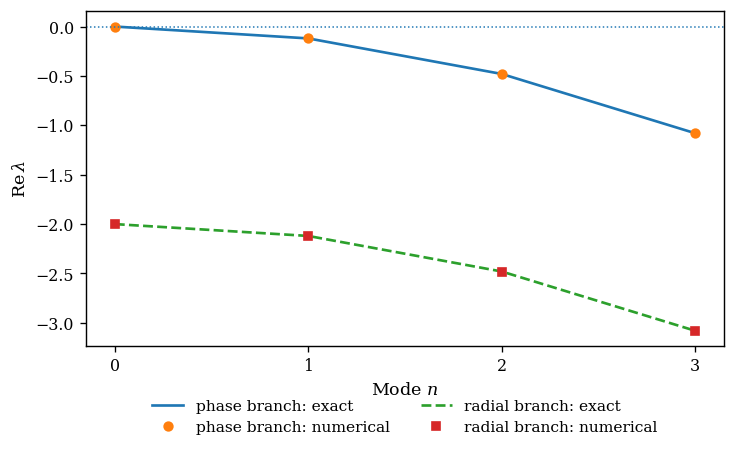

**Figure caption.** Floquet exponents of the spatially homogeneous periodic orbit.  The constant phase mode is neutral, whereas the first nonconstant phase mode has exponent $\lambda_\star=-d(\pi/L)^2$ and is the unique slowest transverse mode.  Markers obtained from the numerical one-period map agree with the exact linearized branches.

In [5]:

# EXPERIMENT 1 — plotting
phase_data = spectrum_results.query("branch == 'phase'")
radial_data = spectrum_results.query("branch == 'radial'")

plt.figure(figsize=PAPER_FIGSIZE)
plt.plot(
    phase_data["mode"],
    phase_data["exact_exponent"],
    "-",
    label="phase branch: exact",
)
plt.plot(
    phase_data["mode"],
    phase_data["numerical_exponent"],
    "o",
    label="phase branch: numerical",
)
plt.plot(
    radial_data["mode"],
    radial_data["exact_exponent"],
    "--",
    label="radial branch: exact",
)
plt.plot(
    radial_data["mode"],
    radial_data["numerical_exponent"],
    "s",
    label="radial branch: numerical",
)
plt.axhline(0.0, linewidth=0.9, linestyle=":")
plt.xlabel("Mode $n$")
plt.ylabel(r"$\operatorname{Re}\lambda$")
plt.xticks(mode_numbers)
plt.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.14), borderaxespad=0.0)
plt.subplots_adjust(bottom=0.24)

finish_figure(
    "figure_1_floquet_spectrum",
    "Floquet exponents of the spatially homogeneous periodic orbit.  The constant phase mode is neutral, whereas the first nonconstant phase mode has exponent $\\lambda_\\star=-d(\\pi/L)^2$ and is the unique slowest transverse mode.  Markers obtained from the numerical one-period map agree with the exact linearized branches.",
)



## Experiment 2 — Convergence of the section eigenfunction $\chi_m$

**Theory checked.**  On the phase section, the target eigenfunction satisfies

$$
\chi(Pz)=\mu_\star\chi(z).
$$

For a seed observable $p$ aligned with the slow adjoint mode, we evaluate

$$
\chi_m(z)=\mu_\star^{-m}p(P^m z).
$$

The plot measures convergence to a high-return reference value.  This is the numerical counterpart of the slow-mode limit formula used as the input to the forward-suspension construction.


In [6]:

# EXPERIMENT 2 — computation
initial_conditions = {
    "near cycle": make_section_state(0.08, fast_amplitude=0.06, radial_amplitude=0.04),
    "moderate": make_section_state(0.20, fast_amplitude=0.10, radial_amplitude=0.08),
    "farther in basin": make_section_state(0.35, fast_amplitude=0.14, radial_amplitude=0.12),
}

return_depths = np.arange(0, 11)
reference_depth = 12
convergence_records = []

for label, state in initial_conditions.items():
    target_depths = np.append(return_depths, reference_depth)
    target_times = target_depths * PERIOD
    returned_states = evolve_to_targets(state, target_times)
    chi_values = np.array([
        np.exp(-LAMBDA_STAR * time) * seed_observable(returned_state)
        for time, returned_state in zip(target_times, returned_states)
    ])
    reference_value = chi_values[-1]

    for depth, value in zip(return_depths, chi_values[:-1]):
        convergence_records.append({
            "initial condition": label,
            "return depth": depth,
            "chi_m": value,
            "reference chi": reference_value,
            "absolute error": abs(value - reference_value),
            "relative error": abs(value - reference_value) / max(abs(reference_value), 1.0e-14),
        })

section_convergence = pd.DataFrame.from_records(convergence_records)
section_convergence.to_csv(
    RESULT_DIR / "experiment_2_section_eigenfunction_convergence.csv",
    index=False,
)

display(
    section_convergence.groupby("initial condition").tail(1)[
        ["initial condition", "chi_m", "reference chi", "relative error"]
    ].round(10)
)


,initial condition,chi_m,reference chi,relative error
10,near cycle,0.077846,0.077846,3.000000e-10
21,moderate,0.189378,0.189378,1.700000e-09
32,farther in basin,0.320048,0.320048,4.700000e-09


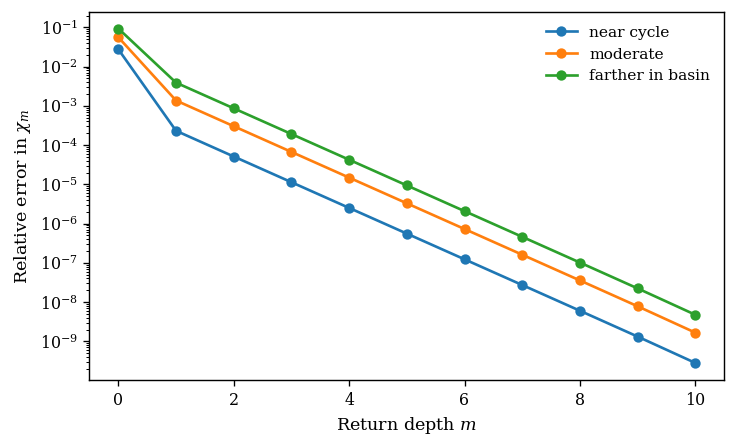

**Figure caption.** Convergence of the return-map approximation $\chi_m=\mu_\star^{-m}p\circ P^m$ for three initial states on the phase section.  The reference value uses twelve returns.  Geometric decay of the error supports the section eigenfunction used in the forward-suspension theorem.

In [7]:

# EXPERIMENT 2 — plotting
plt.figure(figsize=PAPER_FIGSIZE)
for label, group in section_convergence.groupby("initial condition", sort=False):
    plt.semilogy(
        group["return depth"],
        np.maximum(group["relative error"], 1.0e-16),
        marker="o",
        label=label,
    )

plt.xlabel("Return depth $m$")
plt.ylabel(r"Relative error in $\chi_m$")
plt.legend()

finish_figure(
    "figure_2_section_limit",
    "Convergence of the return-map approximation $\\chi_m=\\mu_\\star^{-m}p\\circ P^m$ for three initial states on the phase section.  The reference value uses twelve returns.  Geometric decay of the error supports the section eigenfunction used in the forward-suspension theorem.",
)


## Experiment 3 — Koopman eigenfunction residual

**Theory checked.**  The main target theorem asserts

$$
\psi(\Phi^tW)=e^{\lambda_\star t}\psi(W).
$$

We evaluate the normalized residual

$$
\mathcal{R}_m(t;W_0)=
\frac{|\psi_m(\Phi^tW_0)-e^{\lambda_\star t}\psi_m(W_0)|}
{1+|\psi_m(W_0)|}
$$

for initial conditions at increasing distances from the cycle.  The implementation uses only future section hits; no inverse flow is used.  Between consecutive section crossings the finite-return suspension enforces the exponential law algebraically, while the residual jumps at crossings quantify the finite-$m$ gluing defect.  Experiment 6 below tests the return- and entry-time independence directly.

In [8]:

# EXPERIMENT 3 — computation
residual_cases = [
    ("near cycle", 0.08, 0.30 * np.pi, 0.06, 0.04),
    ("moderate", 0.20, 0.70 * np.pi, 0.10, 0.08),
    ("farther in basin", 0.35, 1.10 * np.pi, 0.14, 0.12),
]

residual_return_depth = 3
residual_times = np.linspace(0.0, 2.5 * PERIOD, 180)
residual_records = []

for label, slow_amp, initial_phase, fast_amp, radial_amp in residual_cases:
    state = make_section_state(slow_amp, fast_amp, radial_amp)
    psi_values = psi_time_series(
        state,
        initial_phase,
        residual_times,
        return_depth=residual_return_depth,
    )
    predicted_values = np.exp(LAMBDA_STAR * residual_times) * psi_values[0]
    residual_values = np.abs(psi_values - predicted_values) / (1.0 + abs(psi_values[0]))

    for time, value, residual in zip(residual_times, psi_values, residual_values):
        residual_records.append({
            "initial condition": label,
            "time": time,
            "time over period": time / PERIOD,
            "psi_m": value,
            "residual": residual,
        })

residual_results = pd.DataFrame.from_records(residual_records)
residual_results.to_csv(
    RESULT_DIR / "experiment_3_koopman_residual.csv",
    index=False,
)

maximum_residuals = residual_results.groupby("initial condition")["residual"].max()
display(maximum_residuals.rename("maximum residual").to_frame())


,maximum residual
initial condition,
farther in basin,1.296564e-05
moderate,1.902916e-06
near cycle,9.308817e-08


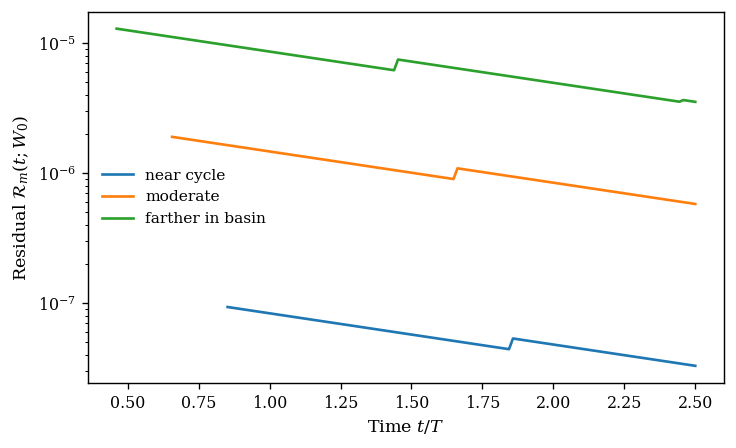

**Figure caption.** Normalized residual for $\psi_m(\Phi^tW_0)=e^{\lambda_\star t}\psi_m(W_0)$, computed with return depth $m=3$.  Initial conditions range from a small perturbation to a state farther inside the basin.  Between section crossings the suspended approximation obeys the exponential law by construction; the visible jumps quantify the finite-return gluing defect.  Their small magnitude is consistent with the local and basin-wide extension formulas, while Experiment 6 directly tests independence from the chosen return and entry times.

In [9]:

# EXPERIMENT 3 — plotting
plt.figure(figsize=PAPER_FIGSIZE)
for label, group in residual_results.groupby("initial condition", sort=False):
    residual = group["residual"].to_numpy().copy()
    residual[residual <= 1.0e-15] = np.nan
    plt.semilogy(
        group["time over period"],
        residual,
        label=label,
    )

plt.xlabel(r"Time $t/T$")
plt.ylabel(r"Residual $\mathcal{R}_m(t;W_0)$")
plt.legend()

finish_figure(
    "figure_3_koopman_residual",
    "Normalized residual for $\\psi_m(\\Phi^tW_0)=e^{\\lambda_\\star t}\\psi_m(W_0)$, computed with return depth $m=3$.  Initial conditions range from a small perturbation to a state farther inside the basin.  Between section crossings the suspended approximation obeys the exponential law by construction; the visible jumps quantify the finite-return gluing defect.  Their small magnitude is consistent with the local and basin-wide extension formulas, while Experiment 6 directly tests independence from the chosen return and entry times.",
)



## Experiment 4 — Derivative--Floquet correspondence

**Theory checked.**  Along the cycle, the derivative of the nonlinear eigenfunctional should be the adjoint Floquet covector:

$$
D\psi(W_\Gamma(\theta))[v]
=
\frac{2}{L}\int_0^L
\operatorname{Im}(e^{-i\theta}v(x))
\cos\!\left(\frac{\pi x}{L}\right)\,dx
$$

under the chosen normalization.  Thus only the first imaginary cosine direction should have unit derivative; the tested radial and faster phase directions should vanish.


In [10]:

# EXPERIMENT 4 — computation
derivative_phase = 0.60 * np.pi
derivative_return_depth = 5
finite_difference_step = 2.0e-4
derivative_modes = np.arange(0, 6)

derivative_records = []
for component in ["real", "imaginary"]:
    for mode in derivative_modes:
        cosine_mode = np.cos(mode * np.pi * X_GRID / L)
        direction = cosine_mode.astype(complex)
        if component == "imaginary":
            direction = 1j * direction

        plus_state = 1.0 + finite_difference_step * direction
        minus_state = 1.0 - finite_difference_step * direction

        plus_value = psi_approximation(
            plus_state,
            derivative_phase,
            derivative_return_depth,
        )
        minus_value = psi_approximation(
            minus_state,
            derivative_phase,
            derivative_return_depth,
        )
        numerical_derivative = (plus_value - minus_value) / (2.0 * finite_difference_step)
        theoretical_derivative = 1.0 if (component == "imaginary" and mode == 1) else 0.0

        derivative_records.append({
            "component": component,
            "mode": mode,
            "numerical derivative": numerical_derivative,
            "theoretical derivative": theoretical_derivative,
        })

derivative_results = pd.DataFrame.from_records(derivative_records)
derivative_results.to_csv(
    RESULT_DIR / "experiment_4_derivative_floquet_alignment.csv",
    index=False,
)

numerical_vector = derivative_results["numerical derivative"].to_numpy()
theoretical_vector = derivative_results["theoretical derivative"].to_numpy()
cosine_similarity = float(
    np.dot(numerical_vector, theoretical_vector)
    / (np.linalg.norm(numerical_vector) * np.linalg.norm(theoretical_vector))
)
relative_covector_error = float(
    np.linalg.norm(numerical_vector - theoretical_vector)
    / np.linalg.norm(theoretical_vector)
)

# A separate phase-invariance check for the slow direction.
phase_samples = np.linspace(0.0, 1.5 * np.pi, 4)
slow_direction = 1j * np.cos(np.pi * X_GRID / L)
phase_check = []
for phase_angle in phase_samples:
    plus_value = psi_approximation(
        1.0 + finite_difference_step * slow_direction,
        phase_angle,
        derivative_return_depth,
    )
    minus_value = psi_approximation(
        1.0 - finite_difference_step * slow_direction,
        phase_angle,
        derivative_return_depth,
    )
    phase_check.append((plus_value - minus_value) / (2.0 * finite_difference_step))

print(f"Cosine similarity with adjoint Floquet covector: {cosine_similarity:.12f}")
print(f"Relative covector error:                         {relative_covector_error:.3e}")
print("Slow-direction derivative at four cycle phases:")
print(np.asarray(phase_check))


Cosine similarity with adjoint Floquet covector: 1.000000000000
Relative covector error:                         8.066e-09
Slow-direction derivative at four cycle phases:
[0.99999999 0.99999999 0.99999999 0.99999999]


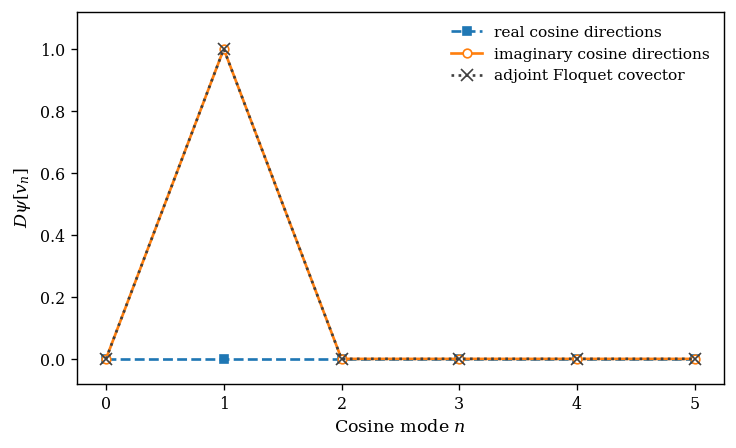

**Figure caption.** Finite-difference directional derivatives of the suspended eigenfunctional along the periodic orbit.  Under the chosen normalization, only the first imaginary cosine direction has unit response.  The numerical derivative therefore aligns with the adjoint Floquet covector, while radial and faster phase directions are annihilated.

In [11]:

# EXPERIMENT 4 — plotting
real_derivatives = derivative_results.query("component == 'real'")
imaginary_derivatives = derivative_results.query("component == 'imaginary'")
theoretical_derivatives = derivative_results.query("component == 'imaginary'")

plt.figure(figsize=PAPER_FIGSIZE)
plt.plot(
    real_derivatives["mode"],
    real_derivatives["numerical derivative"],
    "s--",
    label="real cosine directions",
)
plt.plot(
    imaginary_derivatives["mode"],
    imaginary_derivatives["numerical derivative"],
    "o-",
    markerfacecolor="white",
    label="imaginary cosine directions",
)
plt.plot(
    theoretical_derivatives["mode"],
    theoretical_derivatives["theoretical derivative"],
    "x:",
    color="0.25",
    markersize=7.0,
    zorder=3,
    label="adjoint Floquet covector",
)
plt.xlabel("Cosine mode $n$")
plt.ylabel(r"$D\psi[v_n]$")
plt.xticks(derivative_modes)
plt.ylim(-0.08, 1.12)
plt.legend()

finish_figure(
    "figure_4_derivative_floquet",
    "Finite-difference directional derivatives of the suspended eigenfunctional along the periodic orbit.  Under the chosen normalization, only the first imaginary cosine direction has unit response.  The numerical derivative therefore aligns with the adjoint Floquet covector, while radial and faster phase directions are annihilated.",
)



## Experiment 5 — Koopman eigenvalue lattice

**Theory checked.**  Let

$$
z_\theta(W)=e^{i\theta(W)}
$$

be the phase eigenfunction.  For each $n\in\mathbb Z$,

$$
\psi_n(W)=z_\theta(W)^n\psi(W)
$$

should have exponent

$$
\lambda_n=\lambda_\star+in\omega_0.
$$

We estimate the real decay rate from $\log|\psi_n(t)|$ and the imaginary frequency from the unwrapped complex phase.


In [12]:

# EXPERIMENT 5 — computation
ladder_initial_state = make_section_state(
    slow_amplitude=0.25,
    fast_amplitude=0.10,
    radial_amplitude=0.08,
)
ladder_initial_phase = 0.37 * np.pi
ladder_return_depth = 4
ladder_times = np.linspace(0.0, 2.5 * PERIOD, 240)

base_psi = psi_time_series(
    ladder_initial_state,
    ladder_initial_phase,
    ladder_times,
    return_depth=ladder_return_depth,
)

ladder_indices = np.arange(-2, 3)
ladder_records = []
for ladder_index in ladder_indices:
    phase_factor = np.exp(
        1j * ladder_index * (ladder_initial_phase + OMEGA0 * ladder_times)
    )
    ladder_observable = phase_factor * base_psi

    estimated_real_part = np.polyfit(
        ladder_times,
        np.log(np.abs(ladder_observable)),
        deg=1,
    )[0]
    estimated_imaginary_part = np.polyfit(
        ladder_times,
        np.unwrap(np.angle(ladder_observable)),
        deg=1,
    )[0]

    ladder_records.append({
        "n": ladder_index,
        "target real part": LAMBDA_STAR,
        "estimated real part": estimated_real_part,
        "target imaginary part": ladder_index * OMEGA0,
        "estimated imaginary part": estimated_imaginary_part,
    })

ladder_results = pd.DataFrame.from_records(ladder_records)
ladder_results.to_csv(
    RESULT_DIR / "experiment_5_koopman_eigenvalue_lattice.csv",
    index=False,
)

display(ladder_results.round(10))


,n,target real part,estimated real part,target imaginary part,estimated imaginary part
0,-2,-0.12,-0.119999,-2.0,-2.0
1,-1,-0.12,-0.119999,-1.0,-1.0
2,0,-0.12,-0.119999,0.0,0.0
3,1,-0.12,-0.119999,1.0,1.0
4,2,-0.12,-0.119999,2.0,2.0


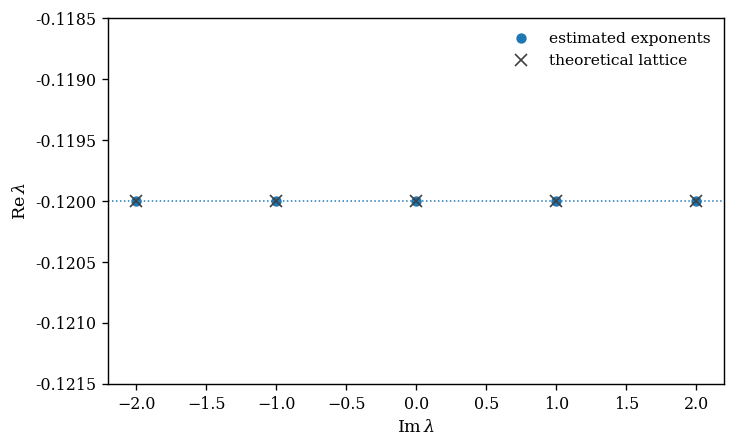

**Figure caption.** Estimated Koopman exponents for $z_\theta^n\psi$, $n=-2,-1,0,1,2$.  All observables share the transverse decay rate $\operatorname{Re}\lambda=\lambda_\star$, while their frequencies are shifted by integer multiples of the cycle frequency, giving the predicted ladder $\lambda_\star+in\omega_0$.

In [13]:
# EXPERIMENT 5 — plotting
from matplotlib.ticker import FormatStrFormatter

plt.figure(figsize=PAPER_FIGSIZE)
plt.plot(
    ladder_results["estimated imaginary part"],
    ladder_results["estimated real part"],
    "o",
    label="estimated exponents",
)
plt.plot(
    ladder_results["target imaginary part"],
    ladder_results["target real part"],
    "x",
    color="0.25",
    markersize=7.0,
    zorder=3,
    label="theoretical lattice",
)
plt.axhline(LAMBDA_STAR, linestyle=":", linewidth=0.9)
plt.xlabel(r"$\operatorname{Im}\lambda$")
plt.ylabel(r"$\operatorname{Re}\lambda$")
plt.ylim(LAMBDA_STAR - 1.5e-3, LAMBDA_STAR + 1.5e-3)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
plt.legend()

finish_figure(
    "figure_5_koopman_eigenvalue_lattice",
    "Estimated Koopman exponents for $z_\\theta^n\\psi$, $n=-2,-1,0,1,2$.  All observables share the transverse decay rate $\\operatorname{Re}\\lambda=\\lambda_\\star$, while their frequencies are shifted by integer multiples of the cycle frequency, giving the predicted ladder $\\lambda_\\star+in\\omega_0$.",
)

## Experiment 6 — Return-choice and entry-time independence

This experiment directly targets the two forward-only statements that distinguish the proposed parabolic-semiflow theory from flow-based constructions.

### 6a. Forward suspension: independence of the chosen future return

Let $\tau(W)$ be the next hitting time of the phase section.  For $q=0,1,2$, use the $q$-th later section hit and define the finite-return candidate

$$
\psi_{m}^{[q]}(W)
=
 e^{-\lambda_\star(\tau(W)+qT)}
 \chi_m\!\left(\Phi^{\tau(W)+qT}W\right).
$$

The exact section eigenfunction satisfies $\chi\circ P=\mu_\star\chi$, so the target forward-suspension lemma predicts that the limiting value is independent of $q$.  We measure

$$
E_m^{\mathrm{return}}(W)
=
\max_{q=1,2}
\frac{|\psi_m^{[q]}(W)-\psi_m^{[0]}(W)|}
     {1+|\psi_m^{[0]}(W)|}.
$$

### 6b. Forward globalization: independence of the entry time

For an initial state outside a prescribed local tube, let $t_{\mathrm{ent}}$ be the first sampled time at which

$$
d_\Gamma(Z)=
\left(\frac1L\int_0^L|Z(x)-1|^2\,dx\right)^{1/2}
$$

falls below the tube radius.  At several later times $t_j\ge t_{\mathrm{ent}}$, define

$$
G_m(t_j;W_0)
=
 e^{-\lambda_\star t_j}
 \psi_m^{\mathrm{loc}}(\Phi^{t_j}W_0).
$$

The target globalization lemma predicts that the limiting value is independent of $t_j$.  The plots below show the finite-$m$ discrepancies and their convergence to zero.

In [14]:
# EXPERIMENT 6 — computation

def cycle_distance(z: np.ndarray) -> float:
    """Normalized L2 distance from the rotating-frame cycle Z=1."""
    return float(
        np.sqrt(np.trapezoid(np.abs(z - 1.0) ** 2, X_GRID) / L)
    )


def return_choice_candidate(
    z0: np.ndarray,
    phase_angle: float,
    return_depth: int,
    additional_returns: int,
) -> float:
    """
    Compute the forward-suspension candidate using the q-th later section hit.

    This implements
        exp[-lambda_*(tau+qT)] chi_m(S^{tau+qT} z0)
    with chi_m=mu_*^{-m} p o P^m.
    """
    hitting_time = (
        time_to_next_section(phase_angle)
        + additional_returns * PERIOD
    )
    section_state = evolve(z0, hitting_time)
    chi_value = chi_approximation(section_state, return_depth)
    return float(np.exp(-LAMBDA_STAR * hitting_time) * chi_value)


# -----------------------------------------------------------------------------
# Experiment 6a: independence of the selected future return.
# -----------------------------------------------------------------------------
choice_cases = [
    ("near cycle", 0.08, 0.30 * np.pi, 0.06, 0.04),
    ("moderate", 0.20, 0.70 * np.pi, 0.10, 0.08),
    ("farther in basin", 0.35, 1.10 * np.pi, 0.14, 0.12),
]
choice_depths = np.arange(0, 9)
return_choices = np.array([0, 1, 2])
return_choice_records = []
return_choice_summary_records = []

for label, slow_amp, phase_angle, fast_amp, radial_amp in choice_cases:
    state = make_section_state(slow_amp, fast_amp, radial_amp)
    case_errors = []

    for depth in choice_depths:
        values = np.array([
            return_choice_candidate(
                state,
                phase_angle,
                return_depth=depth,
                additional_returns=int(q),
            )
            for q in return_choices
        ])
        denominator = 1.0 + abs(values[0])
        discrepancies = np.abs(values - values[0]) / denominator
        maximum_discrepancy = float(np.max(discrepancies[1:]))
        case_errors.append(maximum_discrepancy)

        for q, value, discrepancy in zip(return_choices, values, discrepancies):
            return_choice_records.append({
                "initial condition": label,
                "return depth": int(depth),
                "additional returns q": int(q),
                "candidate value": float(value),
                "normalized discrepancy from q=0": float(discrepancy),
                "maximum discrepancy": maximum_discrepancy,
            })

    positive_errors = np.asarray(case_errors)
    ratios = positive_errors[1:] / positive_errors[:-1]
    return_choice_summary_records.append({
        "initial condition": label,
        "error at m=0": float(positive_errors[0]),
        "error at m=8": float(positive_errors[-1]),
        "median reduction factor": float(np.median(ratios[-4:])),
    })

return_choice_results = pd.DataFrame.from_records(return_choice_records)
return_choice_summary = pd.DataFrame.from_records(return_choice_summary_records)
return_choice_results.to_csv(
    RESULT_DIR / "experiment_6a_return_choice_independence.csv",
    index=False,
)
return_choice_summary.to_csv(
    RESULT_DIR / "experiment_6a_return_choice_summary.csv",
    index=False,
)

# -----------------------------------------------------------------------------
# Experiment 6b: independence of the entry time used in globalization.
# -----------------------------------------------------------------------------
entry_initial_state = make_section_state(
    slow_amplitude=0.48,
    fast_amplitude=0.18,
    radial_amplitude=0.16,
)
entry_initial_phase = 0.83 * np.pi
local_tube_radius = 0.14

# Detect the first sampled entry into the prescribed local tube.
entry_scan_times = np.linspace(0.0, 5.0 * PERIOD, 501)
entry_scan_states = evolve_to_targets(entry_initial_state, entry_scan_times)
entry_scan_distances = np.array([
    cycle_distance(state) for state in entry_scan_states
])
entry_indices = np.flatnonzero(entry_scan_distances <= local_tube_radius)
if len(entry_indices) == 0:
    raise RuntimeError("The test trajectory did not enter the prescribed local tube.")

entry_index = int(entry_indices[0])
first_entry_time = float(entry_scan_times[entry_index])
first_entry_distance = float(entry_scan_distances[entry_index])

# All comparison times lie after first entry.  Some share the same next section,
# while others use later section returns, so both local consistency and genuine
# entry-time independence are exercised.
entry_time_shifts_over_period = np.array([0.0, 0.40, 1.20, 2.15])
entry_times = first_entry_time + entry_time_shifts_over_period * PERIOD
entry_states = evolve_to_targets(entry_initial_state, entry_times)
entry_distances = np.array([cycle_distance(state) for state in entry_states])
entry_depths = np.arange(0, 9)
entry_records = []
entry_summary_records = []

for depth in entry_depths:
    candidates = []
    for entry_time, entry_state, entry_distance, shift in zip(
        entry_times,
        entry_states,
        entry_distances,
        entry_time_shifts_over_period,
    ):
        local_value = psi_approximation(
            entry_state,
            entry_initial_phase + OMEGA0 * entry_time,
            return_depth=int(depth),
        )
        global_candidate = float(
            np.exp(-LAMBDA_STAR * entry_time) * local_value
        )
        candidates.append(global_candidate)

    candidates = np.asarray(candidates)
    denominator = 1.0 + abs(candidates[0])
    discrepancies = np.abs(candidates - candidates[0]) / denominator

    for shift, entry_time, entry_distance, candidate, discrepancy in zip(
        entry_time_shifts_over_period,
        entry_times,
        entry_distances,
        candidates,
        discrepancies,
    ):
        entry_records.append({
            "return depth": int(depth),
            "entry shift over period": float(shift),
            "entry time": float(entry_time),
            "entry distance": float(entry_distance),
            "globalization candidate": float(candidate),
            "normalized discrepancy from first entry": float(discrepancy),
        })

entry_independence_results = pd.DataFrame.from_records(entry_records)
entry_independence_results.to_csv(
    RESULT_DIR / "experiment_6b_entry_time_independence.csv",
    index=False,
)

for shift in entry_time_shifts_over_period[1:]:
    group = entry_independence_results.query(
        "`entry shift over period` == @shift"
    ).sort_values("return depth")
    errors = group["normalized discrepancy from first entry"].to_numpy()
    positive = np.maximum(errors, 1.0e-30)
    ratios = positive[1:] / positive[:-1]
    entry_summary_records.append({
        "entry shift over period": float(shift),
        "entry time": float(group["entry time"].iloc[0]),
        "entry distance": float(group["entry distance"].iloc[0]),
        "error at m=0": float(errors[0]),
        "error at m=8": float(errors[-1]),
        "median reduction factor": float(np.median(ratios[-4:])),
    })

entry_summary = pd.DataFrame.from_records(entry_summary_records)
entry_summary.to_csv(
    RESULT_DIR / "experiment_6b_entry_time_summary.csv",
    index=False,
)

print("Return-choice consistency summary")
display(return_choice_summary)
print(f"First local-tube entry: t/T={first_entry_time / PERIOD:.3f}, "
      f"distance={first_entry_distance:.6f}, radius={local_tube_radius:.3f}")
print("Entry-time consistency summary")
display(entry_summary)

Return-choice consistency summary


,initial condition,error at m=0,error at m=8,median reduction factor
0,near cycle,0.000020,1.148742e-10,0.221361
1,moderate,0.000355,2.026356e-09,0.221360
2,farther in basin,0.002098,1.191460e-08,0.221360


First local-tube entry: t/T=1.010, distance=0.139198, radius=0.140
Entry-time consistency summary


,entry shift over period,entry time,entry distance,error at m=0,error at m=8,median reduction factor
0,0.40,8.859291,0.103078,1.171548e-16,5.618725e-15,1.014312
1,1.20,13.885840,0.056447,6.521516e-04,3.765109e-09,0.221360
2,2.15,19.854866,0.027587,7.967692e-04,4.598550e-09,0.221360


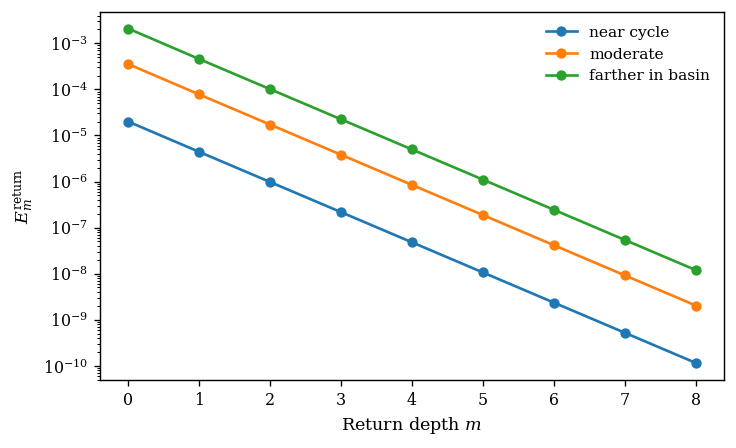

**Figure caption.** Finite-return discrepancy obtained by defining the suspended amplitude from the next section hit or from one and two additional returns.  For the exact return-map eigenfunction these choices are identical.  The geometric decay of $E_m^{\mathrm{return}}$ for states at three distances from the cycle directly corroborates the return-number independence in the forward-suspension and gluing lemma.

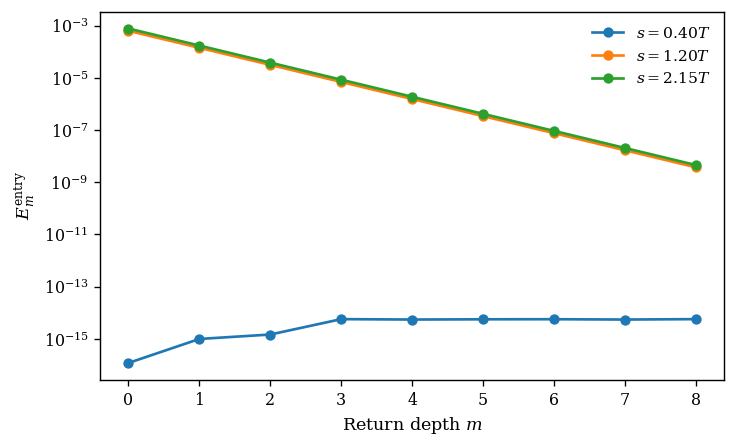

**Figure caption.** Normalized differences among basin-wide amplitudes computed from several admissible entry times after the trajectory first reaches the local tube $d_\Gamma(Z)\leq 0.14$.  The candidate $e^{-\lambda_\star t_j}\psi_m^{\mathrm{loc}}(\Phi^{t_j}W_0)$ approaches an entry-time-independent value as the return depth increases, directly corroborating the forward-globalization lemma.  The $0.40T$ shift shares the same future section and agrees to time-stepping accuracy; later-section choices exhibit geometric convergence.

In [15]:
# EXPERIMENT 6 — plotting

# Figure 6: return-choice independence.
return_error_curves = (
    return_choice_results
    .groupby(["initial condition", "return depth"], sort=False)["maximum discrepancy"]
    .first()
    .reset_index()
)

plt.figure(figsize=PAPER_FIGSIZE)
for label, group in return_error_curves.groupby("initial condition", sort=False):
    plt.semilogy(
        group["return depth"],
        np.maximum(group["maximum discrepancy"], 1.0e-16),
        marker="o",
        label=label,
    )

plt.xlabel("Return depth $m$")
plt.ylabel(r"$E_m^{\mathrm{return}}$")
plt.legend()

finish_figure(
    "figure_6_return_choice_independence",
    "Finite-return discrepancy obtained by defining the suspended amplitude from the next section hit or from one and two additional returns.  For the exact return-map eigenfunction these choices are identical.  The geometric decay of $E_m^{\\mathrm{return}}$ for states at three distances from the cycle directly corroborates the return-number independence in the forward-suspension and gluing lemma.",
)

# Figure 7: entry-time independence.
plt.figure(figsize=PAPER_FIGSIZE)
for shift, group in entry_independence_results.groupby(
    "entry shift over period", sort=True
):
    if abs(shift) < 1.0e-14:
        continue
    plt.semilogy(
        group["return depth"],
        np.maximum(
            group["normalized discrepancy from first entry"],
            1.0e-16,
        ),
        marker="o",
        label=rf"$s={shift:.2f}T$",
    )

plt.xlabel("Return depth $m$")
plt.ylabel(r"$E_m^{\mathrm{entry}}$")
plt.legend()

finish_figure(
    "figure_7_entry_time_independence",
    "Normalized differences among basin-wide amplitudes computed from several admissible entry times after the trajectory first reaches the local tube $d_\\Gamma(Z)\\leq 0.14$.  The candidate $e^{-\\lambda_\\star t_j}\\psi_m^{\\mathrm{loc}}(\\Phi^{t_j}W_0)$ approaches an entry-time-independent value as the return depth increases, directly corroborating the forward-globalization lemma.  The $0.40T$ shift shares the same future section and agrees to time-stepping accuracy; later-section choices exhibit geometric convergence.",
)

## Interpretation and paper use

The six tests support different parts of the theoretical framework:

| Experiment | Theoretical statement supported |
|---|---|
| 1. Floquet spectrum | spectral assumptions and identification of the unique slow multiplier |
| 2. Section limit | construction of the normalized return-map eigenfunction $\chi$ |
| 3. Koopman eigenfunction residual | continuous-time exponential law and the finite-return gluing defect across section crossings |
| 4. Derivative alignment | identification of $D\psi|_\Gamma$ with the selected adjoint Floquet covector |
| 5. Koopman eigenvalue lattice | corollary $z_\theta^n\psi$ with exponent $\lambda_\star+in\omega_0$ |
| 6. Choice independence | return-number independence in section-to-continuous-time extension and entry-time independence in basin-wide globalization |

The figures are saved in both PDF and 300-dpi PNG formats.  Captions are also collected in

```text
figures/figure_captions.md
```

Experiment 6 is the most direct numerical check of the paper's specifically **semiflow** contribution: it compares different definitions that the proposed lemmas assert must agree, without using negative-time evolution.  The observed finite-return discrepancies should decay to zero as $m$ increases.

These computations corroborate the constructive consequences of the theory; they do not replace proofs of existence, conditional uniqueness, Fréchet $C^r$ regularity, or topological nonexistence statements.  The notebook deliberately does **not** test the negative-multiplier/double-cover theorem, because the chosen Stuart--Landau reaction--diffusion benchmark has a positive slow multiplier.  A separate topologically nontrivial example should be added only if it is mathematically natural rather than artificially engineered.